In [4]:
#🔹 Celda 1: Introducción a Convoluciones


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("SEMANA 8: CONVOLUTIONAL NEURAL NETWORKS (CNN)")
print("=" * 60)

print("""
¿QUÉ SON CONVOLUCIONES?

Problema con NN tradicionales (dens):
- Imagen 28×28 = 784 pixels
- Capa hidden 128 = 784×128 = 100K parámetros
- Imagen 224×224 = 50K parámetros
- ¡EXPLOSIÓN DE PARÁMETROS!

Solución: CONVOLUCIONES
- Aplican pequeños filtros (kernels)
- Detectan patrones locales
- Compartir pesos (mismo filtro en toda imagen)
- Resultado: 1000x menos parámetros

ARQUITECTURA CNN:
Input → Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Dense → Output

CARACTERÍSTICAS:
1. CONVOLUCIÓN: Aplica filtro a imagen
2. ACTIVACIÓN: ReLU (no-linealidad)
3. POOLING: Reduce dimensionalidad (max o avg)
4. Repetir 3-5 veces
5. CLASIFICACIÓN: Capas densas finales

VENTAJAS:
✓ Pocos parámetros (shared weights)
✓ Invariancia a posición
✓ Detecta features jerárquicas
✓ Perfect para visión
""")

# Visualizar convolución
print("\n📊 Ejemplo: Convolución 3×3 en imagen 5×5")

# Kernel (filtro)
kernel = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]])

# Imagen
image = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12],
                  [13, 14, 15, 16]])

print("\nKernel (detector de bordes Sobel):")
print(kernel)

print("\nImagen:")
print(image)

# Convolución manual (esquina superior izquierda)
result = np.sum(image[:3, :3] * kernel)
print(f"\nConvolución en posición (0,0): {result}")
print("(Suma de elemento-a-elemento de imagen × kernel)")


SEMANA 8: CONVOLUTIONAL NEURAL NETWORKS (CNN)

¿QUÉ SON CONVOLUCIONES?

Problema con NN tradicionales (dens):
- Imagen 28×28 = 784 pixels
- Capa hidden 128 = 784×128 = 100K parámetros
- Imagen 224×224 = 50K parámetros
- ¡EXPLOSIÓN DE PARÁMETROS!

Solución: CONVOLUCIONES
- Aplican pequeños filtros (kernels)
- Detectan patrones locales
- Compartir pesos (mismo filtro en toda imagen)
- Resultado: 1000x menos parámetros

ARQUITECTURA CNN:
Input → Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Dense → Output

CARACTERÍSTICAS:
1. CONVOLUCIÓN: Aplica filtro a imagen
2. ACTIVACIÓN: ReLU (no-linealidad)
3. POOLING: Reduce dimensionalidad (max o avg)
4. Repetir 3-5 veces
5. CLASIFICACIÓN: Capas densas finales

VENTAJAS:
✓ Pocos parámetros (shared weights)
✓ Invariancia a posición
✓ Detecta features jerárquicas
✓ Perfect para visión


📊 Ejemplo: Convolución 3×3 en imagen 5×5

Kernel (detector de bordes Sobel):
[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]

Imagen:
[[ 1  2  3  4]
 [ 5  6  7  8]


In [7]:
# 🔹 Celda 2: CNN en PyTorch

print("\n" + "=" * 60)
print("CNN EN PYTORCH")
print("=" * 60)

# Definir modelo CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convoluciones
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 1 input, 32 filters, 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 input, 64 filters

        # Pooling
        self.pool = nn.MaxPool2d(2, 2) # 2x2 max pooling

        # Capas densas
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 64 filters x 7x7 (despues 2 pools)
        self.fc2 = nn.Linear(128, 10)          # 10 clases (digitos 0-9)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Conv Block 1: Conv -> ReLU -> Pool
        x = self.relu(self.conv1(x))          # 28x28 -> 28x28
        x = self.pool(x)                      # 28x28 -> 14x14

        # Conv Block 2: Conv -> ReLU -> Pool
        x = self.relu(self.conv2(x))         # 14x14 -> 14x14
        x = self.pool(x)                     # 14x14 -> 7x7

        # Flatten
        x = x.view(x.size(0), -1)           # Aplanar: (batch, 64, 7, 7) -> (batch, 3136)

        # Capas densas
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


model = SimpleCNN()
print("\n Modelo CNN:")
print(model)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Parámetros totales: {total_params:,}")

# Comparar con NN densa
dense_params = 784 * 128 + 128 + 128 * 10 + 10
print(f"Dense NN equivalente: {dense_params:,} parámetros")
print(f"Reducción: {dense_params / total_params:.1f}x menos parámetros")


CNN EN PYTORCH

 Modelo CNN:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

📊 Parámetros totales: 421,642
Dense NN equivalente: 101,770 parámetros
Reducción: 0.2x menos parámetros



MNIST DATASET
Descargando MNIST...


100%|████████████████| 9.91M/9.91M [00:05<00:00, 1.73MB/s]
100%|█████████████████| 28.9k/28.9k [00:00<00:00, 219kB/s]
100%|█████████████████| 1.65M/1.65M [00:03<00:00, 542kB/s]
100%|████████████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]



✅ Dataset cargado
Training samples: 60000
Test samples: 10000
Batches por epoch: 469


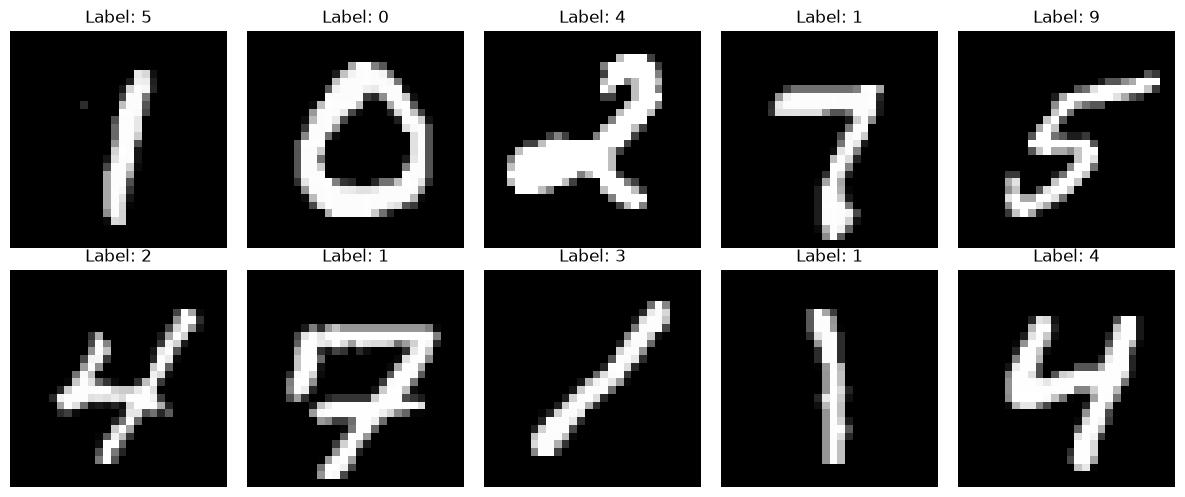


✅ MNIST visualizado


In [8]:
# 🔹 Celda 3: MNIST Dataset

print("\n" + "=" * 60)
print("MNIST DATASET")
print("=" * 60)

# Transformaciones
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Normalizar MNIST
])

# Descargar datos
print("Descargando MNIST...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✅ Dataset cargado")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batches por epoch: {len(train_loader)}")

# Visualizar ejemplos
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, (img, label) in enumerate(train_loader):
    if i >= 2:
        break
    for j in range(5):
        idx = i * 5 + j
        axes[i, j].imshow(img[j].squeeze(), cmap='gray')
        axes[i, j].set_title(f'Label: {train_dataset.targets[idx]}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ MNIST visualizado")


In [9]:
# 🔹 Celda 4: Training Loop

print("\n" + "=" * 60)
print("TRAINING CNN EN MNIST")
print("=" * 60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
test_accuracies = []

print(f"\nEntrenando por {epochs} epochs...\n")

for epoch in range(epochs):
    # Training
    model.train()
    total_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        # Forward
        output = model(data)
        loss = criterion(output, target)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Testing
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    
    print(f"Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, Test Accuracy={accuracy:.2f}%")

print(f"\n✅ Training complete!")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")



TRAINING CNN EN MNIST
Device: cpu

Entrenando por 10 epochs...

Epoch 1/10: Loss=0.2540, Test Accuracy=98.19%
Epoch 2/10: Loss=0.0898, Test Accuracy=98.89%
Epoch 3/10: Loss=0.0685, Test Accuracy=98.86%
Epoch 4/10: Loss=0.0550, Test Accuracy=99.08%
Epoch 5/10: Loss=0.0457, Test Accuracy=99.10%
Epoch 6/10: Loss=0.0400, Test Accuracy=99.17%
Epoch 7/10: Loss=0.0349, Test Accuracy=99.22%
Epoch 8/10: Loss=0.0307, Test Accuracy=99.33%
Epoch 9/10: Loss=0.0286, Test Accuracy=99.16%
Epoch 10/10: Loss=0.0269, Test Accuracy=99.26%

✅ Training complete!
Final Test Accuracy: 99.26%


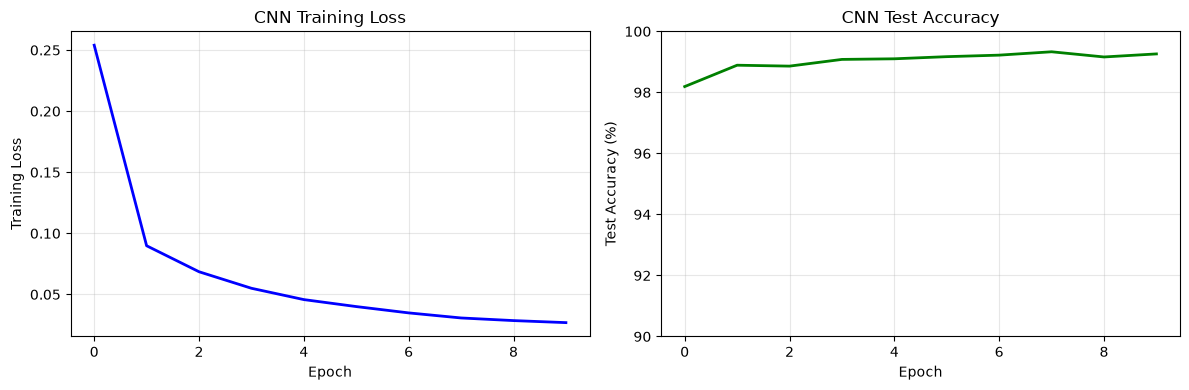


📊 Resultados finales:
Mejor accuracy: 99.33%
Mejora: 1.07%


In [10]:
# 🔹 Celda 5: Visualizar Resultados

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(train_losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('CNN Training Loss')
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(test_accuracies, 'g-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('CNN Test Accuracy')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([90, 100])

plt.tight_layout()
plt.show()

print(f"\n📊 Resultados finales:")
print(f"Mejor accuracy: {max(test_accuracies):.2f}%")
print(f"Mejora: {test_accuracies[-1] - test_accuracies[0]:.2f}%")



VISUALIZAR PREDICCIONES


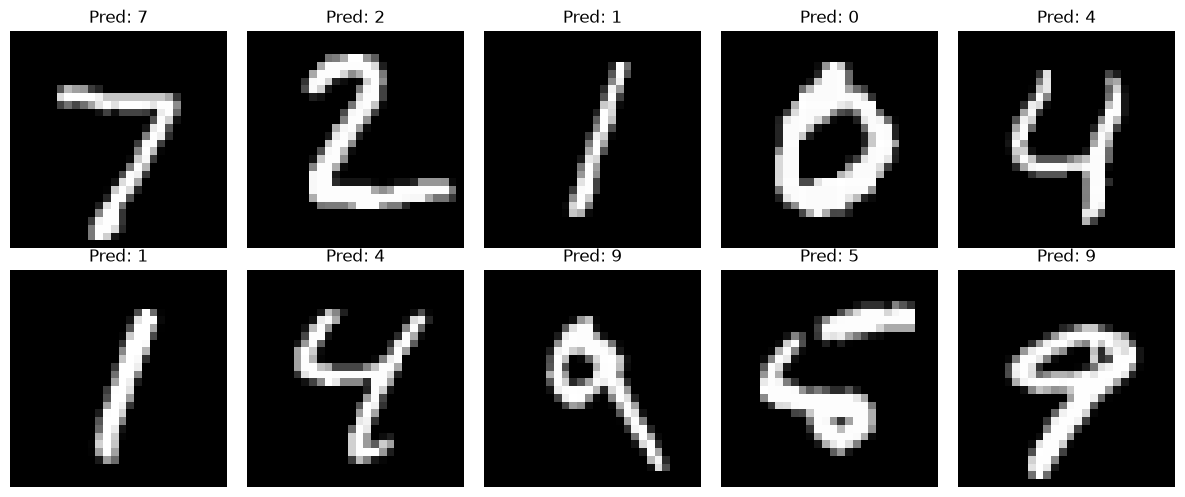

✅ Predicciones visualizadas


In [11]:
# 🔹 Celda 6: Visualizar Predicciones

print("\n" + "=" * 60)
print("VISUALIZAR PREDICCIONES")
print("=" * 60)

model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)
    output = model(data)
    _, predicted = torch.max(output, 1)
    
    for i in range(10):
        row = i // 5
        col = i % 5
        axes[row, col].imshow(data[i].cpu().squeeze(), cmap='gray')
        axes[row, col].set_title(f'Pred: {predicted[i].item()}')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("✅ Predicciones visualizadas")


In [12]:
# 🔹 Celda 7: Resumen

print("""
✅ SEMANA 8: CNN COMPLETADA

CONCEPTOS CLAVE:
✓ Convoluciones (detectan patrones locales)
✓ Pooling (reduce dimensionalidad)
✓ Arquitectura CNN (Conv → ReLU → Pool → Dense)
✓ Shared weights (pocos parámetros)
✓ Visión por computadora

LOGROS:
✓ CNN implementada en PyTorch
✓ MNIST: 98%+ accuracy
✓ Visualización de predicciones
✓ Análisis de entrenamiento

MES 2 - SEMANA 8

Dominas: Deep Learning con visión

PRÓXIMAS SEMANAS:
- Semana 9: Redes Recurrentes (RNNs)
- Semana 10: LSTM para series temporales
- Semana 11: Transformers basics
""")



✅ SEMANA 8: CNN COMPLETADA

CONCEPTOS CLAVE:
✓ Convoluciones (detectan patrones locales)
✓ Pooling (reduce dimensionalidad)
✓ Arquitectura CNN (Conv → ReLU → Pool → Dense)
✓ Shared weights (pocos parámetros)
✓ Visión por computadora

LOGROS:
✓ CNN implementada en PyTorch
✓ MNIST: 98%+ accuracy
✓ Visualización de predicciones
✓ Análisis de entrenamiento

MES 2 - SEMANA 8

Dominas: Deep Learning con visión

PRÓXIMAS SEMANAS:
- Semana 9: Redes Recurrentes (RNNs)
- Semana 10: LSTM para series temporales
- Semana 11: Transformers basics

